In [9]:
## this code is a combination of (i) sensitivity curve generation from full and sliced datasets from Anjana and Jeremy, and (ii) single-source population manipulation from Dave.

In [1]:
import numpy as np
import json, copy
import hasasia.sensitivity as hsen
import hasasia.skymap as hsky
import hasasia.utils as hutils
import hasasia.sim as hsim
import holodeck as holo
import matplotlib.pyplot as plt
from astropy import units as utils
from astropy import constants as c
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.cm as cm
#from la_forge.utils import set_publication_params
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import holodeck as holo
from holodeck.constants import GYR, MSOL, PC, YR

import scipy.linalg as sl
import discovery as ds


# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

### Sarah's data : NG20 with DMX

In [3]:
 ##get ng20 data
import glob
ng20_gwb = '/Users/ashokan/osu/sarahspta/ng20bridgesims/NG20v1p1_dmx_sims/NG20v1p1_dmx_gwb_real042/'
pardir = ng20_gwb
timdir = ng20_gwb
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))
#check number of pulsars
print(len(pars))
print(len(tims))

#check first par and tim files
print(pars[0])
print(tims[0])



80
80
/Users/ashokan/osu/sarahspta/ng20bridgesims/NG20v1p1_dmx_sims/NG20v1p1_dmx_gwb_real042/B1855+09.par
/Users/ashokan/osu/sarahspta/ng20bridgesims/NG20v1p1_dmx_sims/NG20v1p1_dmx_gwb_real042/B1855+09.tim


In [4]:
dPsrs = []
feather_files = sorted(glob.glob(ng20_gwb+'*.feather'))
for feather in feather_files:
    #ds.Pulsar.load_feather(feather)
    dPsrs.append(ds.Pulsar.read_feather(feather))


In [5]:
Tspan = hsen.get_Tspan(dPsrs)
fyr = 1/(365.25*24*3600)
freqs = np.logspace(np.log10(1/(5*Tspan)),np.log10(2e-7),600)
#freqs = np.logspace(np.log10(1/(T5span)),np.log10(2e-7),600)

In [6]:
#red noise dictionary 
noise_dict = '/Users/ashokan/osu/sarahspta/ng20bridgesims/NG20v1p1_dmx_sims/20yr_noisedict_rn+curn-bpl.json'
with open(noise_dict,'r') as f:
    rn_noise = json.load(f)

In [7]:
def make_corr_our(psr):
    sigma_sqrt = psr.toaerrs**2
    corr = np.diag(sigma_sqrt)
    return corr


In [8]:
A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
psrs = []
thin = 1
rn_psrs = rn_noise
for ePsr in dPsrs:
    corr = make_corr_our(ePsr)#[::thin,::thin]
    #nihans_corr = make_corr(ePsr,nihans_noise)
    plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
    if ePsr.name in rn_psrs.keys():
        Amp, gam = rn_psrs[ePsr.name]
        plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

    corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                               toas=ePsr.toas[:])
    psr = hsen.Pulsar(toas=ePsr.toas[:],
                      toaerrs=ePsr.toaerrs[:],
                      phi=ePsr.phi,theta=ePsr.theta,
                      N=corr, designmatrix=ePsr.Mmat[:])
    psr.name = ePsr.name
    psrs.append(psr)
    del ePsr
    print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

PSR J2322+2057 complete

In [9]:
#make spectra
#make spectra
specs = []
for p in psrs:
    print(p.name)
    sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
    _ = sp.NcalInv
    specs.append(sp)
    print('\rPSR {0} complete'.format(p.name),end='',flush=True)
ng20_sens = hsen.GWBSensitivityCurve(specs)

B1855+09
PSR B1855+09 completeB1937+21
PSR B1937+21 completeB1953+29
PSR B1953+29 completeJ0023+0923
PSR J0023+0923 completeJ0030+0451
PSR J0030+0451 completeJ0102+4839
PSR J0102+4839 completeJ0125-2327
PSR J0125-2327 completeJ0154+1833
PSR J0154+1833 completeJ0218+4232
PSR J0218+4232 completeJ0340+4130
PSR J0340+4130 completeJ0406+3039
PSR J0406+3039 completeJ0437-4715
PSR J0437-4715 completeJ0509+0856
PSR J0509+0856 completeJ0557+1551
PSR J0557+1551 completeJ0605+3757
PSR J0605+3757 completeJ0610-2100
PSR J0610-2100 completeJ0613-0200
PSR J0613-0200 completeJ0614-3329
PSR J0614-3329 completeJ0621+2514
PSR J0621+2514 completeJ0636+5128
PSR J0636+5128 completeJ0645+5158
PSR J0645+5158 completeJ0709+0458
PSR J0709+0458 completeJ0732+2314
PSR J0732+2314 completeJ0740+6620
PSR J0740+6620 completeJ0751+1807
PSR J0751+1807 completeJ0931-1902
PSR J0931-1902 completeJ1012+5307
PSR J1012+5307 completeJ1012-4235
PSR J1012-4235 completeJ1022+1001
PSR J1022+1001 completeJ1024-0719
PSR J1024-0719 

/opt/homebrew/Caskroom/mambaforge/base/envs/sarahspta/lib/python3.12/site-packages/hasasia/sensitivity.py:1249: RuntimeWarning: divide by zero encountered in divide
  self._S_I = 1/resid_response(self.freqs)/self.NcalInv


In [10]:
alpha_gwb = (3. - gamma_gwb) / 2.
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
snr_20 = ng20_sens.SNR(S_h)
print(snr_20)

6.039612114179428


In [11]:
#slice
def get_sliced_spectra(psrs, freqs,
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects
        
    cutoff : float
        MJD cutoff for the calculation
    
    sigma_correction : ?
        ???
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
    #         idxs.append(idx)
            pass
        else:
            psrs_cut.append(psr)
    timespan = hsen.get_Tspan(psrs_cut)
    spectra = []
    for idx, p in enumerate(psrs_cut):
        sp = hsen.Spectrum(p,freqs=freqs,amp_gw=None, gamma_gw=None)
        sp.name = p.name
        _ = sp.NcalInv
        #print(f"psr spectra {idx} is done")
        spectra.append(sp)
    print(f"PTA spectrum with {len(spectra)} psrs and tspan {timespan/365.25/24/3600:.1f} created.")
    return spectra

In [12]:
end_mjd = 59033
psr_spectra = get_sliced_spectra(psrs, freqs,
                       start_mjd=1,
                       end_mjd = end_mjd,
                       )

PTA spectrum with 67 psrs and tspan 15.9 created.


In [13]:
sliced_GWBSC = hsen.GWBSensitivityCurve(spectra=psr_spectra, orf='hd', autocorr=False)
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
sliced_SNR = sliced_GWBSC.SNR(S_h)
print(sliced_SNR)

8.201112910814803


### 0) Realistic SNR from this sensitivity curve for bins of 1/T, 2/T .. 30/T

In [14]:
def SNR_chunky(S_eff, Sh, freqs, Tspan):
        """
        Calculate the signal-to-noise ratio of a given signal strain power
        spectral density, `Sh`. Calculate the SNR over the specificied frequencies.
        """
        integrand = Sh**2 / S_eff**2
        SNR = np.sqrt(2.0 * Tspan * np.trapezoid(y=integrand,
                                                   x=freqs,
                                                   axis=0))
        return SNR, freqs, integrand

In [15]:
#full 20 year
Tspan_20 = hsen.get_Tspan(specs)
print('Tspan_20:', Tspan_20/(365*86400))
freqs_20 = np.linspace(1/Tspan_20, 30/Tspan_20, 30)
ng20_mask = np.array([np.argmin(np.abs(freqs - f20)) for f20 in freqs_20])
print('freqs_20:', freqs[ng20_mask])
print('len(freqs_20):', len(freqs[ng20_mask]))
S_h_20 = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs_20)
snr_20_chunky, freqs_20, integrand_20 = SNR_chunky(ng20_sens.S_eff[ng20_mask], S_h_20, freqs_20, Tspan_20)
print('snr_20_chunky:', snr_20_chunky)

Tspan_20: 20.6342733217929
freqs_20: [1.53978662e-09 3.07650117e-09 4.59028301e-09 6.14686436e-09
 7.71412854e-09 9.17140786e-09 1.07866931e-08 1.22814650e-08
 1.38329627e-08 1.54128665e-08 1.69884910e-08 1.85237697e-08
 1.99805353e-08 2.15518655e-08 2.29967145e-08 2.45384270e-08
 2.61834968e-08 2.76383270e-08 2.91739917e-08 3.07949824e-08
 3.21563869e-08 3.39430880e-08 3.54436659e-08 3.70105823e-08
 3.82310636e-08 3.99212071e-08 4.16860696e-08 4.30607324e-08
 4.44807268e-08 4.59475478e-08]
len(freqs_20): 30
snr_20_chunky: 5.809367231830926


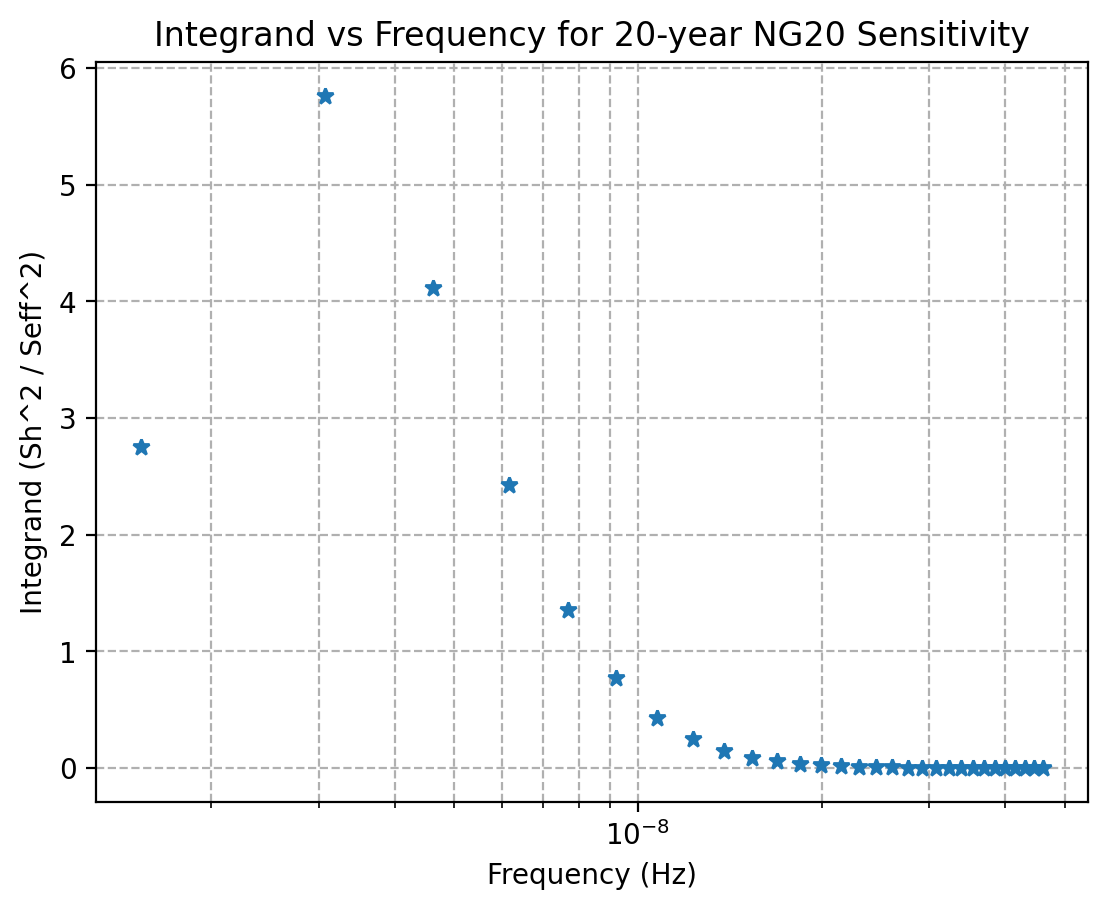

In [16]:
plt.plot(freqs_20, integrand_20,'*')
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Integrand (Sh^2 / Seff^2)')
plt.title('Integrand vs Frequency for 20-year NG20 Sensitivity')
plt.grid(which='both', ls='--')
plt.show()

In [17]:
#15year slice
Tspan_15 = 502576288.3556185 #found from doing hsen.get_Tspan(psr_spectra) on a sliced spectra
print('Tspan_15:', Tspan_15/(365*86400))
freqs_15 = np.linspace(1/Tspan_15, 30/Tspan_15, 30)
ng15_mask = np.array([np.argmin(np.abs(freqs - f15)) for f15 in freqs_15])
print('freqs_15:', freqs[ng15_mask])
print('len(freqs_15):', len(freqs[ng15_mask]))
S_h_15 = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs_15)
snr_15_chunky = SNR_chunky(sliced_GWBSC.S_eff[ng15_mask], S_h_15, freqs_15, Tspan_15)
print('snr_15_chunky:', snr_15_chunky)


Tspan_15: 15.93658955972915
freqs_15: [1.99610896e-09 3.98823545e-09 5.95063301e-09 7.96851389e-09
 1.00002435e-08 1.18893938e-08 1.39833757e-08 1.59211297e-08
 1.79324203e-08 1.99805353e-08 2.17862101e-08 2.37550668e-08
 2.59018524e-08 2.79388529e-08 2.98118891e-08 3.18104947e-08
 3.39430880e-08 3.58290633e-08 3.78198289e-08 3.99212071e-08
 4.16860696e-08 4.40022672e-08 4.59475478e-08 4.79788266e-08
 4.95610028e-08 5.17520275e-08 5.34586309e-08 5.58219645e-08
 5.76627804e-08 5.95643000e-08]
len(freqs_15): 30
snr_15_chunky: (np.float64(8.000739475773178), array([1.98974767e-09, 3.97949534e-09, 5.96924302e-09, 7.95899069e-09,
       9.94873836e-09, 1.19384860e-08, 1.39282337e-08, 1.59179814e-08,
       1.79077291e-08, 1.98974767e-08, 2.18872244e-08, 2.38769721e-08,
       2.58667197e-08, 2.78564674e-08, 2.98462151e-08, 3.18359628e-08,
       3.38257104e-08, 3.58154581e-08, 3.78052058e-08, 3.97949534e-08,
       4.17847011e-08, 4.37744488e-08, 4.57641965e-08, 4.77539441e-08,
       4.974

In [18]:
#lets get the continuous frequency integrand 
def SNR(sc, Sh):
    """
    Calculate the signal-to-noise ratio of a given signal strain power
    spectral density, `Sh`. Must match frequency range and `df` of
    `self`.
    """
    integrand = Sh**2 / sc.S_eff**2
    SNR = np.sqrt(2.0 * sc.Tspan * np.trapezoid(y=integrand,
                                                x=sc.freqs,
                                                axis=0))
    return SNR, sc.freqs, integrand

6.039612114179428


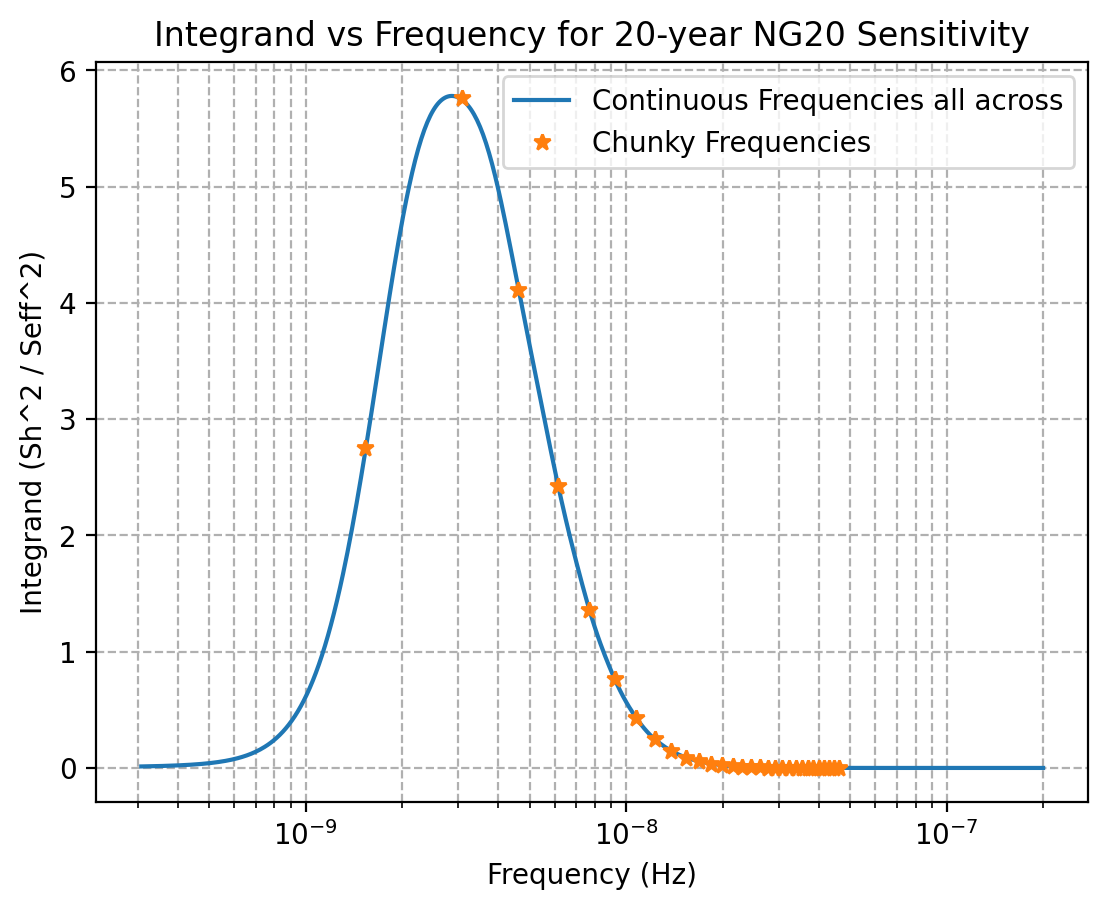

In [19]:
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
snr_20,freqs_cont, integrand_cont = SNR(ng20_sens,S_h)
print(snr_20)
plt.plot(freqs_cont, integrand_cont,label='Continuous Frequencies all across')
plt.plot(freqs_20, integrand_20,'*',label='Chunky Frequencies')
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Integrand (Sh^2 / Seff^2)')
plt.grid(which='both', ls='--')
plt.title('Integrand vs Frequency for 20-year NG20 Sensitivity')
plt.legend()
plt.show()

6.039612114179428


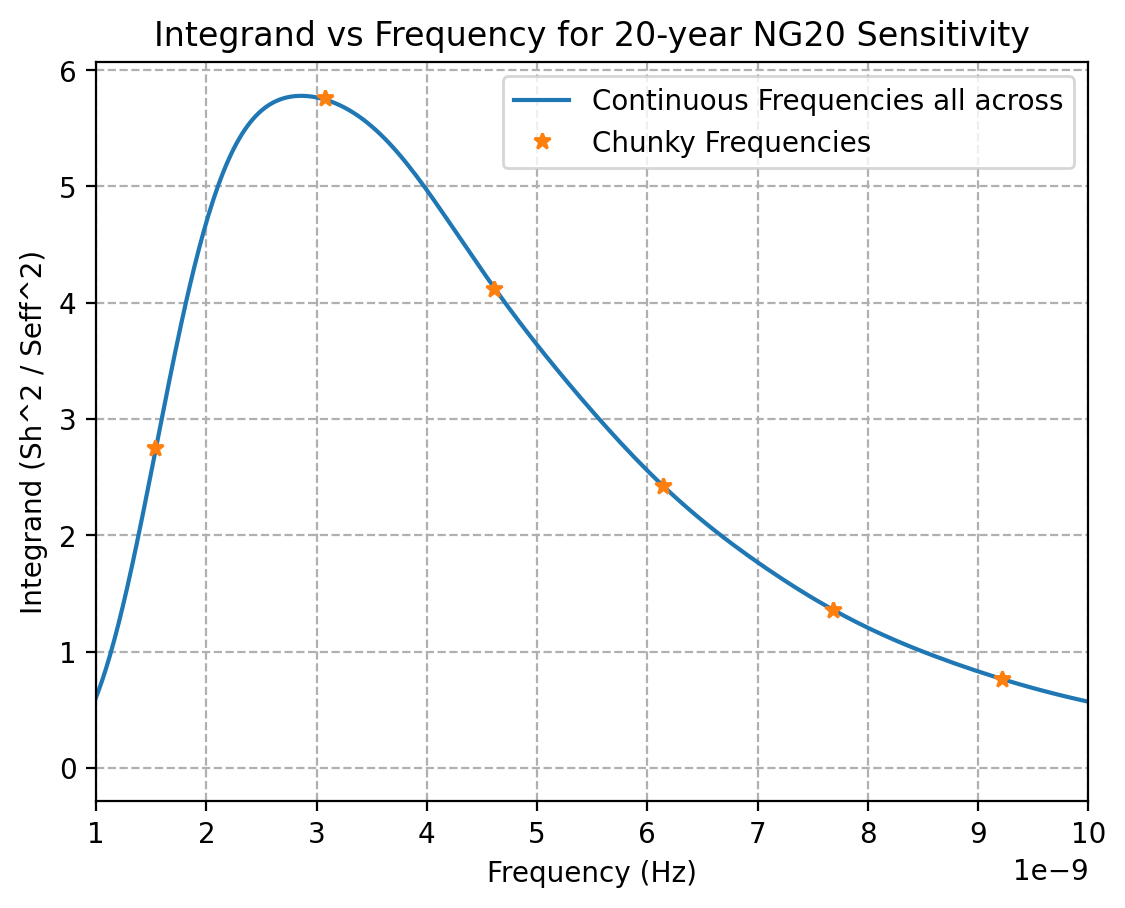

In [20]:
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
snr_20,freqs_cont, integrand_cont = SNR(ng20_sens,S_h)
print(snr_20)
plt.plot(freqs_cont, integrand_cont,label='Continuous Frequencies all across')
plt.plot(freqs_20, integrand_20,'*',label='Chunky Frequencies')
#plt.xscale('log')
plt.xlim(1e-9, 1e-8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Integrand (Sh^2 / Seff^2)')
plt.grid(which='both', ls='--')
plt.title('Integrand vs Frequency for 20-year NG20 Sensitivity')
plt.legend()
plt.show()

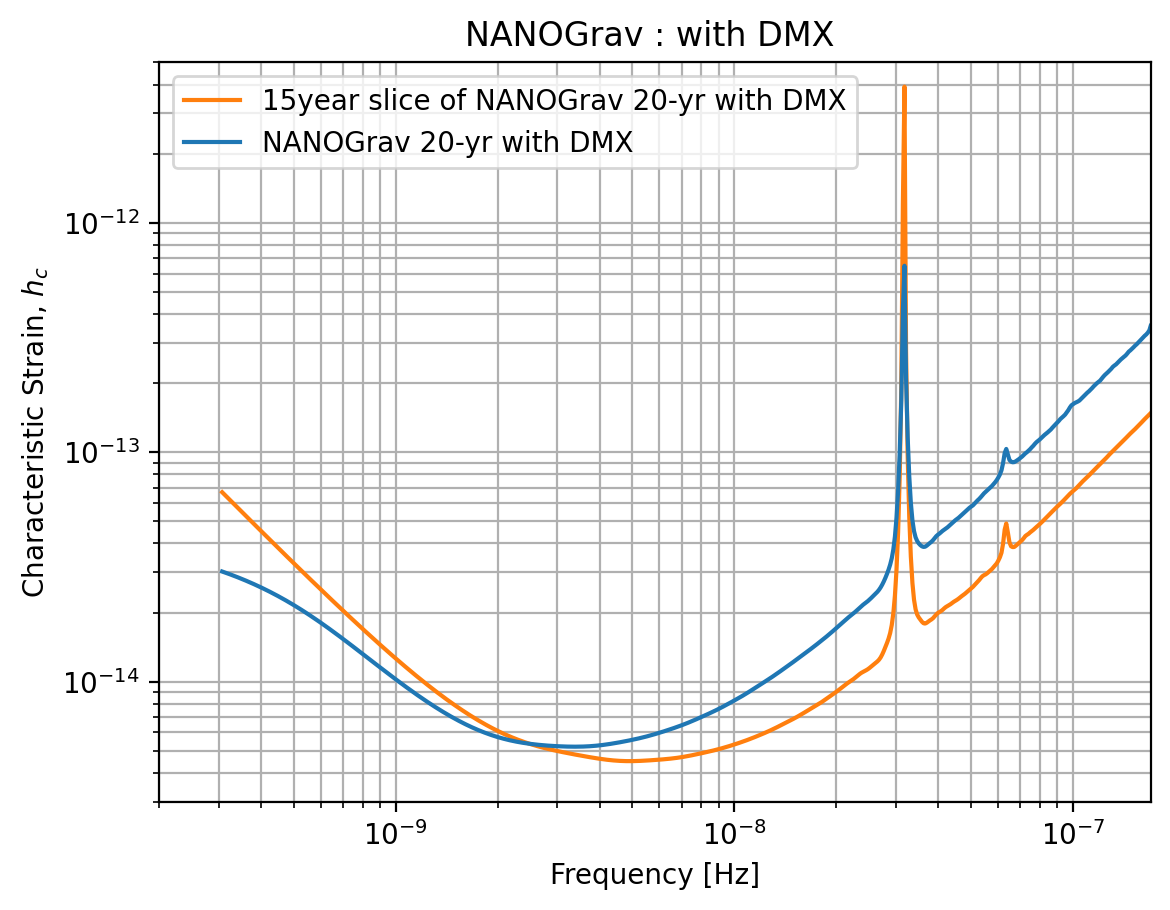

In [21]:
#plot 15year slice of NG20 against NG15

plt.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr with DMX')
plt.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr with DMX')



plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title(
'NANOGrav : with DMX ')#, SNR={:.1f}'.format(
 #   sliced_SNR
#)


#plt.title('NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}'.format(FACTOR),'SNR={:.2f}'.format(sliced_with_factor_SNR))

plt.grid(which='both')
plt.ylim(3e-15,5e-12)
plt.xlim(2e-10,1.7e-7)
plt.legend()
plt.savefig("ng20_ng15_with_dmx_sensitivity_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## 1) Sensitivity comparison between NG15 and NG20 for GWB

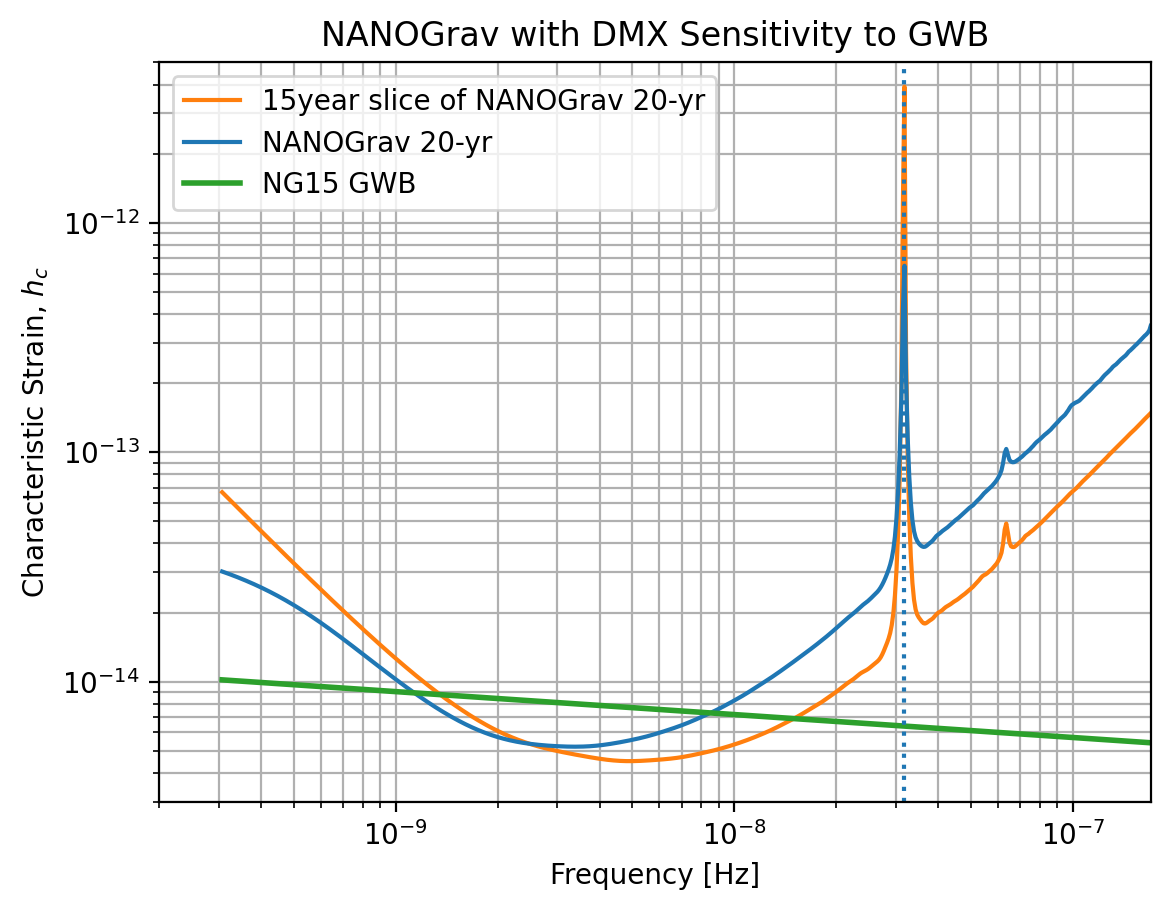

In [22]:
h = 6.4e-15
gamma_gwb = 3.2
alpha_gwb = (3. - gamma_gwb) / 2. 
plaw = np.dot((ng20_sens.freqs[:]/fyr)**alpha_gwb,
              h)
import pickle
ng15_pkl_gwb = '/Users/ashokan/osu/sarahspta/ng15yr_v1p1_pint_logf_m2a_red_noise_vg_gwbsc.has' 
with open (ng15_pkl_gwb,'rb') as f:
    ng15_sc_gwb = pickle.load(f)

#plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,color='C3',label='Original NG15')
plt.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr')
plt.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr')
plt.loglog(ng20_sens.freqs,plaw,lw=2,color='C2',label='NG15 GWB')

plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.axvline(fyr,linestyle=':')
plt.rc('text', usetex=False)
plt.title('NANOGrav with DMX Sensitivity to GWB')
plt.ylim(3e-15,5e-12)
plt.xlim(2e-10,1.7e-7)
# plt.text(x=4e-8,y=3e-15,
#          s=r'$A_{\rm GWB}$='+'{0:1.2e}'.format(hgw),
#          bbox=dict(facecolor='white', alpha=0.6))
plt.grid(which='both')
plt.legend(loc='upper left')
plt.savefig("ng20_ng15_with_dmx_sensitivity_comparison_gwb.png", dpi=300, bbox_inches='tight')
plt.show()

## 2) Sensitivity comparison between NG15 and NG20 for CWs

### Dave's single source population

In [23]:
import h5py
data = h5py.File('pop-draw-sims.h5', 'r') 

In [24]:
data.keys()

<KeysViewHDF5 ['fobs_orb_edges', 'gsmf_mchar0_log10', 'gsmf_phi0', 'hard_gamma_inner', 'hard_time', 'hc_bg', 'hc_ss', 'mmb_mamp_log10', 'mmb_scatter_dex']>

In [25]:
len(data['hc_bg']), len(data['hc_ss']),len(data["fobs_orb_edges"])

(100, 100, 100)

In [26]:
print(data["fobs_orb_edges"][0])

[7.69128345e-10 2.30738504e-09 3.84564173e-09 5.38389842e-09
 6.92215511e-09 8.46041180e-09 9.99866849e-09 1.15369252e-08
 1.30751819e-08 1.46134386e-08 1.61516952e-08 1.76899519e-08
 1.92282086e-08 2.07664653e-08 2.23047220e-08 2.38429787e-08
 2.53812354e-08 2.69194921e-08 2.84577488e-08 2.99960055e-08
 3.15342621e-08 3.30725188e-08 3.46107755e-08 3.61490322e-08
 3.76872889e-08 3.92255456e-08 4.07638023e-08 4.23020590e-08
 4.38403157e-08 4.53785724e-08 4.69168290e-08 4.84550857e-08
 4.99933424e-08 5.15315991e-08 5.30698558e-08 5.46081125e-08
 5.61463692e-08 5.76846259e-08 5.92228826e-08 6.07611393e-08
 6.22993959e-08 6.38376526e-08 6.53759093e-08 6.69141660e-08
 6.84524227e-08 6.99906794e-08 7.15289361e-08 7.30671928e-08
 7.46054495e-08 7.61437062e-08 7.76819628e-08 7.92202195e-08
 8.07584762e-08 8.22967329e-08 8.38349896e-08 8.53732463e-08
 8.69115030e-08 8.84497597e-08 8.99880164e-08 9.15262731e-08
 9.30645297e-08]


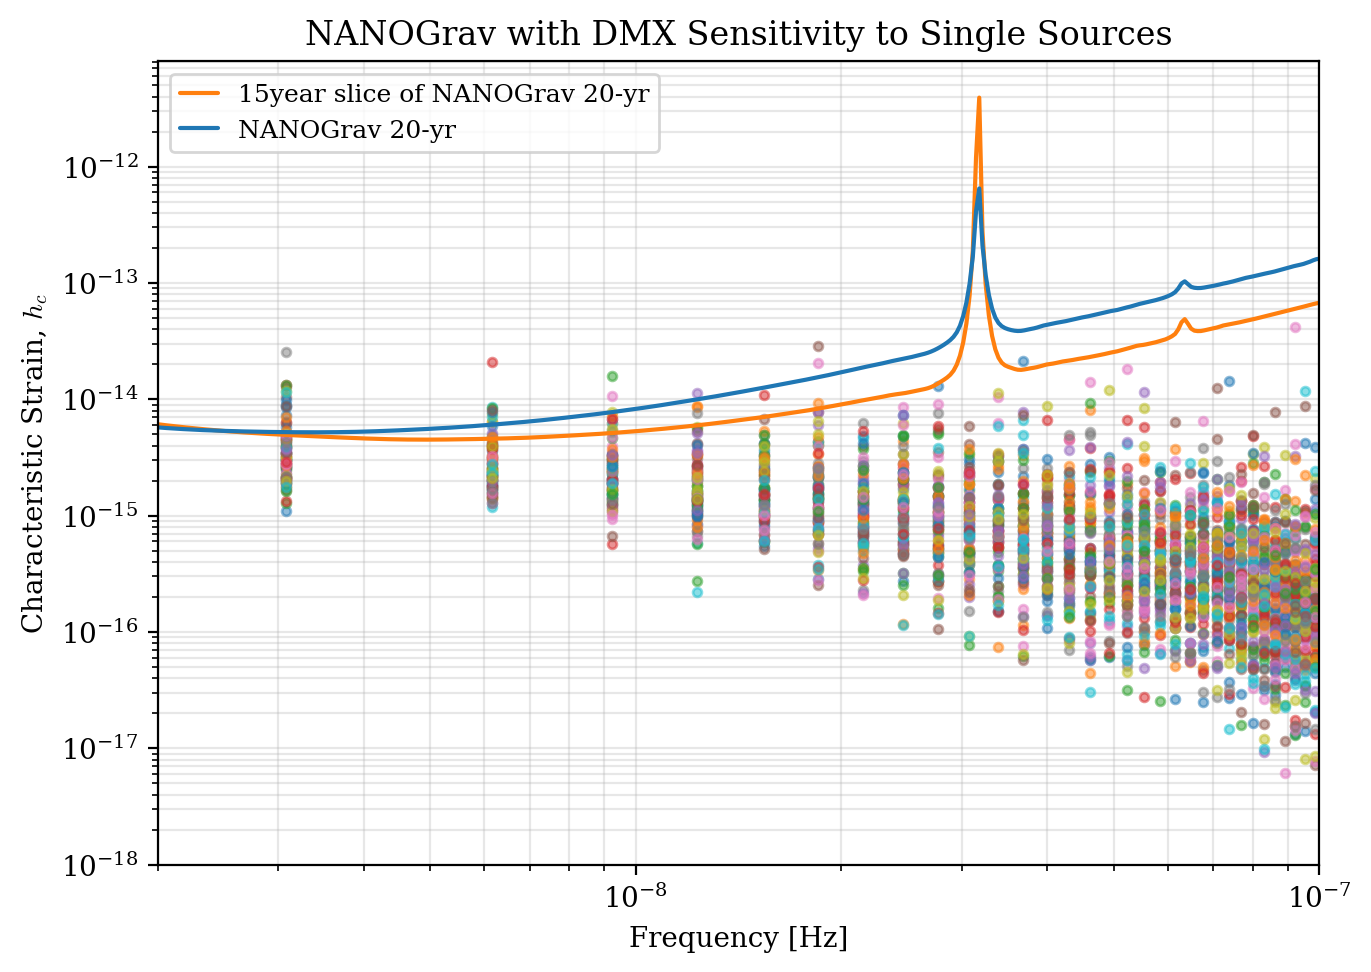

In [27]:
from holodeck import cosmo, plot, utils
from holodeck.constants import GYR, MSOL, PC, YR
from holodeck.librarian import posterior_populations as postpop
# Number of realizations to plot
plot_num_reals = 10
plot_num_params = 10
# Number of loudest-binaries-per-bin to plot
plot_num_loudest = 1

# ---- Load data

# Frequency bin edges, in units of [1/sec], for orbital frequencies
fobs_orb_edges = data["fobs_orb_edges"][0]  # Just need the first one, they're all the same
# convert to GW frequency centers (assuming circular orbits)
fobs_orb_cents = 0.5 * (fobs_orb_edges[1:] + fobs_orb_edges[:-1])
fobs_gw_cents = 2.0 * fobs_orb_cents #* YR

# Characteristic strains of the L loudest binaries in each of F frequency bins for each of R realizations
# shape: (NParReals, F, R, L)
hc_ss = data["hc_ss"]
npar_reals, nfreqs, nreals, nloudest = hc_ss.shape 
# Characteristic strain of all *other* binaries (i.e. All minus L)
# shape: (NParReals, F, R)
hc_bg = data["hc_bg"]

# can't plot more elements than we have in the data
plot_num_reals = np.minimum(plot_num_reals, nreals)
plot_num_params = np.minimum(plot_num_params, npar_reals)
plot_num_loudest = np.minimum(plot_num_loudest, nloudest)

# ---- Plot GW signals

fig, ax = holo.plot.figax()
for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # this is the combined GWs from all binaries except `L` loudest in each frequency bin
        bg = hc_bg[nr, :, rr]
        # add back in the strains from the loudest binaries that we aren't plotting
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            # Add in quadrature, summing over however many loudest binaries remain
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))
         
        #(hh,) = ax.plot(fobs_gw_cents, bg, alpha=0.75)
        for ll in range(plot_num_loudest):
            ax.scatter(
                fobs_gw_cents, hc_ss[nr, :, rr, ll], s=10, alpha=0.5
            )
            
# Plot a -2/3 power-law of amplitude 1e-15 for reference
#hc_plaw = 1.0e-15 * np.power(fobs_gw_cents, -2.0 / 3.0)
#ax.plot(fobs_gw_cents, hc_plaw, "k--", alpha=0.5, lw=1.0)

#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,color='C3',label='Original NG15')
ax.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr')
#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlim(2e-9,1e-7)
# ---- Labels, legend, and grid
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title(
    'NANOGrav with DMX Sensitivity to Single Sources'#\n'
    #f'SNR={sliced_SNR:.2f}'
)
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.ylim(3e-15,5e-12)
# plt.xlim(2e-10,1.7e-7)
plt.tight_layout()
#plt.show()
plt.savefig("ng20_ng15_with_dmx_sensitivity_comparison_cws.png", dpi=300, bbox_inches='tight')
plt.show()

#### In a color scheme that matches the GWB version

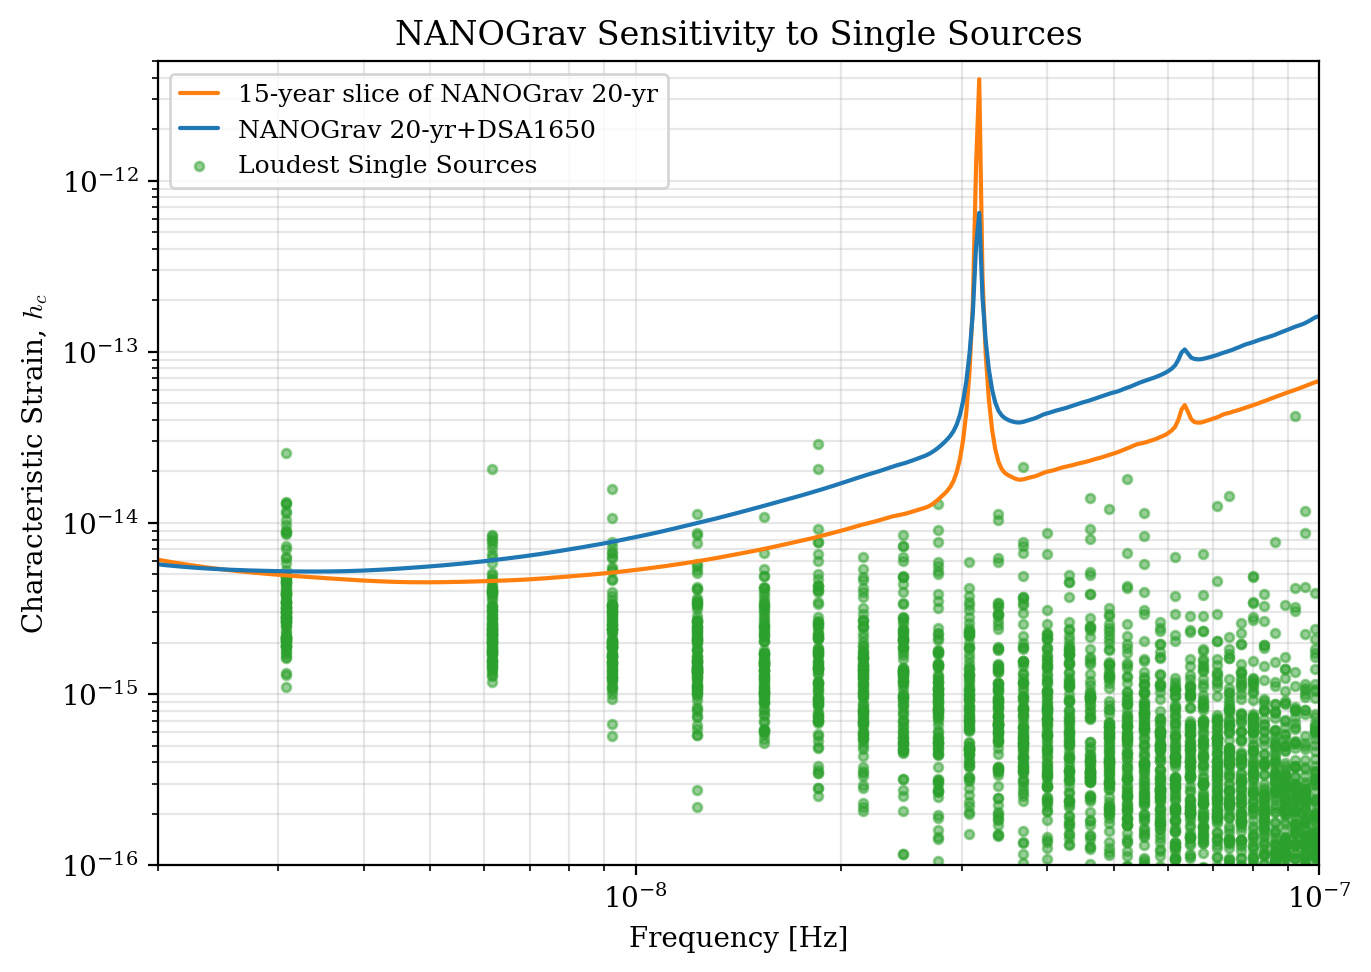

In [30]:
fig, ax = holo.plot.figax()

# Sensiticity curves
#ax.loglog(ng15_sc_gwb.freqs, ng15_sc_gwb.h_c, color='C3', label='Original NG15')
ax.loglog(sliced_GWBSC.freqs, sliced_GWBSC.h_c, color='C1', label='15-year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs, ng20_sens.h_c, color='C0', label='NANOGrav 20-yr+DSA1650')

# Flag to only label the single-source scatter once
labeled_single_sources = False
single_source_color = 'C2'  # choose any matplotlib color (C0–C9, or 'gray', etc.)

for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # Combined GWs from all binaries except `L` loudest
        bg = hc_bg[nr, :, rr]

        # Add in remaining loudest binaries (if any)
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))

        # Plot the single sources (same color for all)
        for ll in range(plot_num_loudest):
            if not labeled_single_sources:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll],
                    s=10,
                    alpha=0.5,
                    color=single_source_color,
                    label='Loudest Single Sources'
                )
                labeled_single_sources = True
            else:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll],
                    s=10,
                    alpha=0.5,
                    color=single_source_color
                )


# Axis setup and labels
plt.xlim(2e-9, 1e-7)
plt.ylim(1e-16,5e-12)
# plt.ylim(3e-15,5e-12)
# plt.xlim(2e-10,1.7e-7)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title('NANOGrav Sensitivity to Single Sources')
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig("ng20_ng15_with_dmx_sensitivity_comparison_cws.png", dpi=300, bbox_inches='tight')
plt.show()


### 3) Single source detection volume

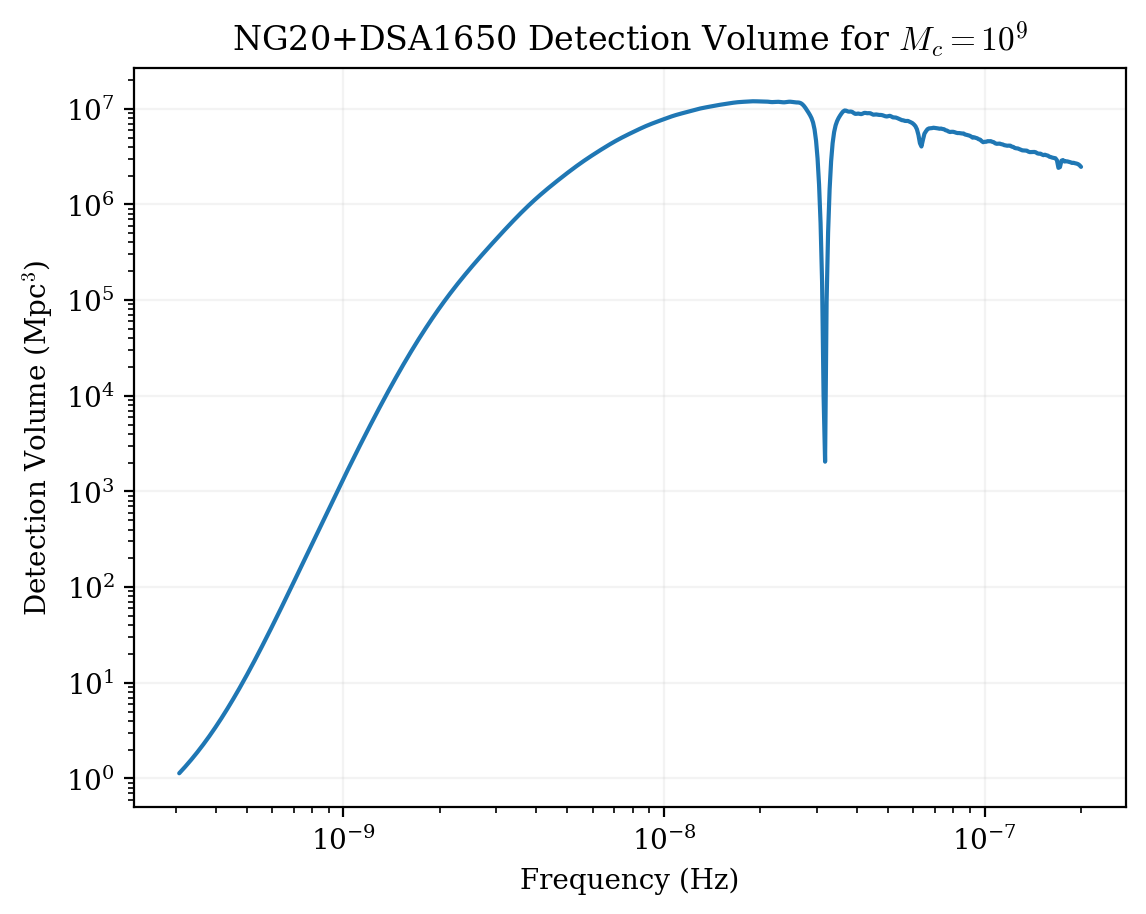

In [31]:
#plot skymap for hc
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)
SM_full_20=hsky.SkySensitivity(specs,theta_gw, phi_gw)
dv_full_20 = SM_full_20.calculate_detection_volume(f0=freqs, SNR_threshold=5, M_c=1e9)
plt.loglog(freqs,dv_full_20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Detection Volume (Mpc$^3$)')
plt.title('NG20+DSA1650 Detection Volume for $M_c=10^9$')
plt.savefig('ng20_ng15_with_dmx_detection_volume_mc1e9.png',dpi=300)
plt.show()

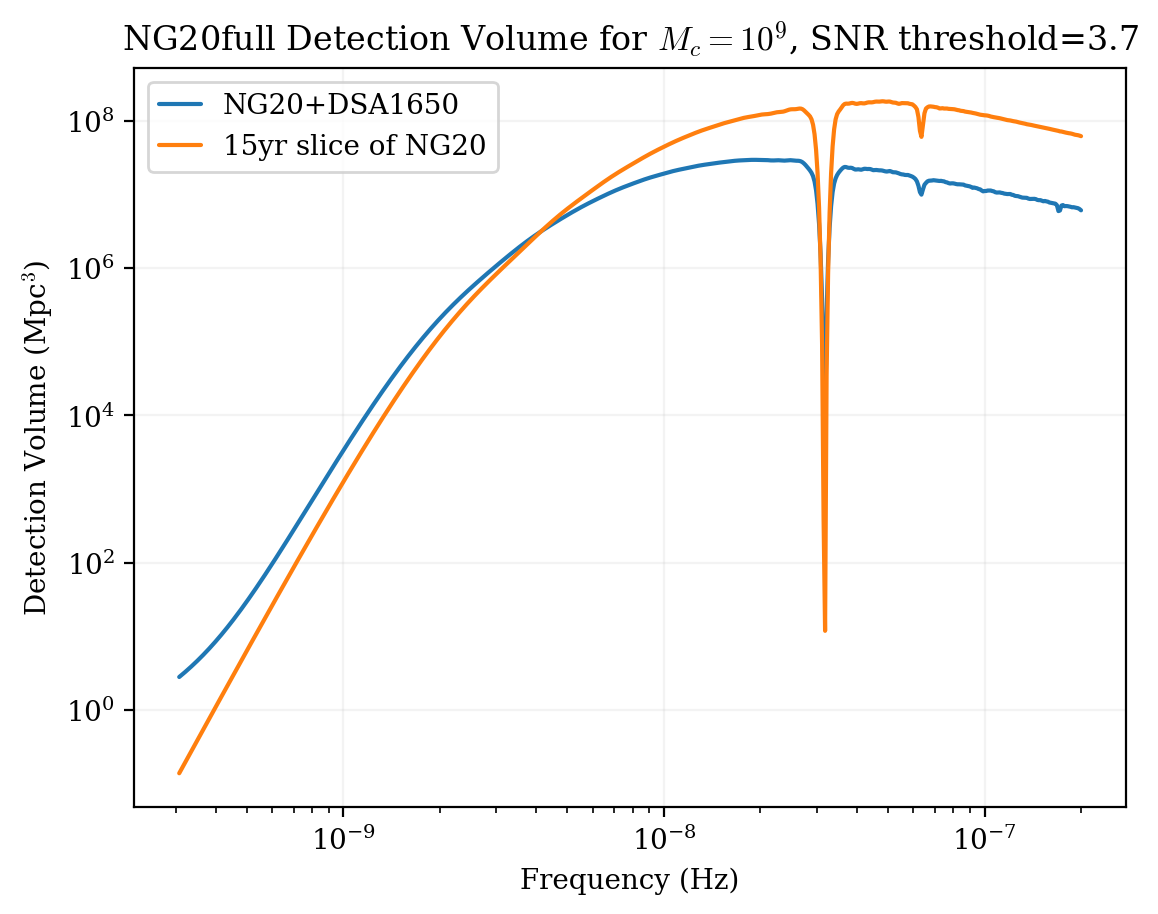

1/Tspan_DSA: 20.6342733217929
1.5367535114635838e-09


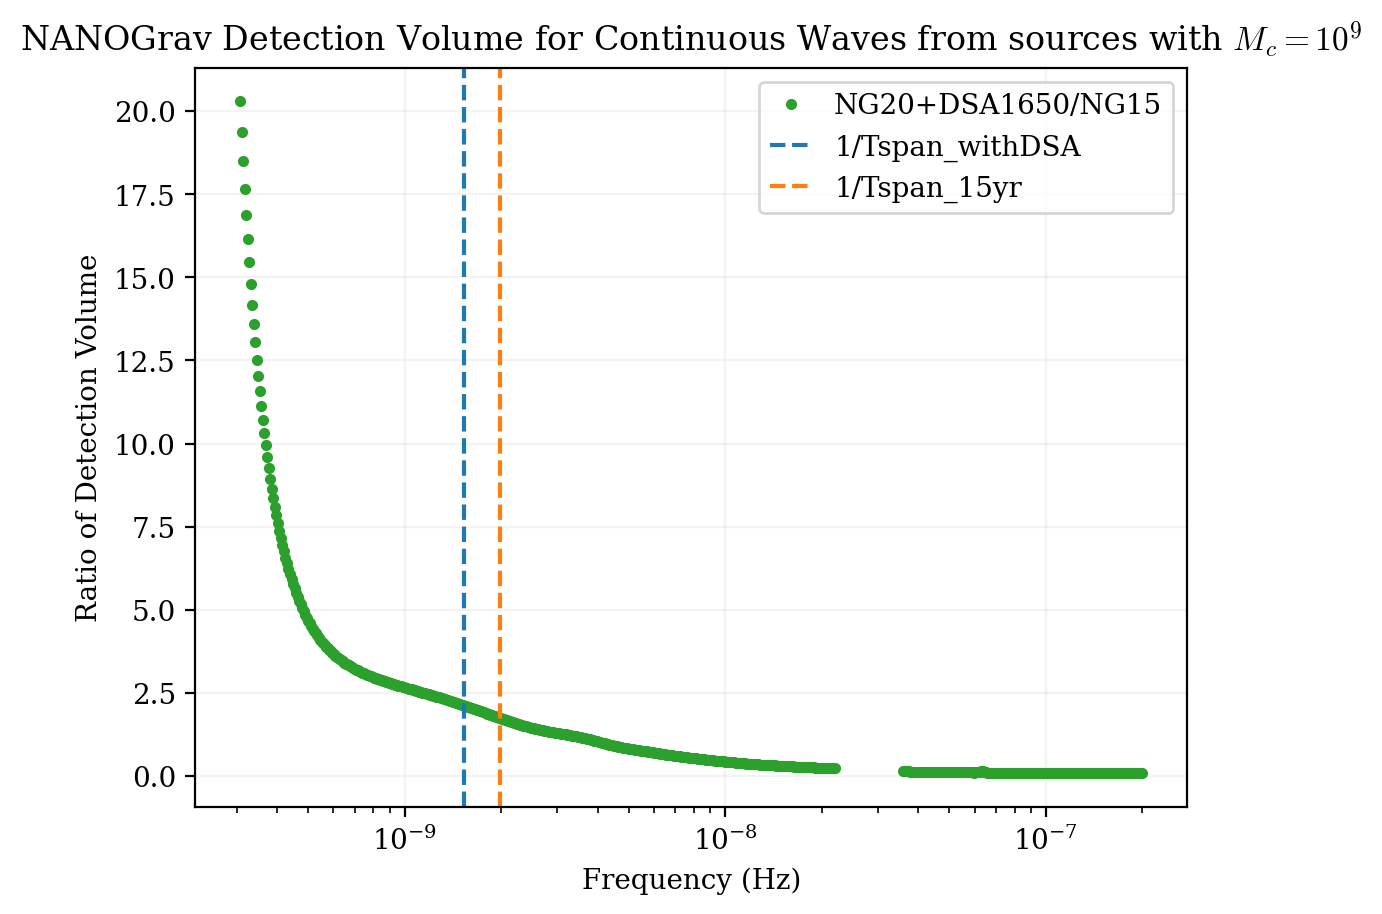

In [32]:
dv_full_20 = SM_full_20.calculate_detection_volume(f0=freqs, SNR_threshold=3.7, M_c=1e9)
SM_15yr_20=hsky.SkySensitivity(psr_spectra,theta_gw, phi_gw)
dv_15yr_20 = SM_15yr_20.calculate_detection_volume(f0=freqs, SNR_threshold=3.7, M_c=1e9)
plt.loglog(freqs,dv_full_20,label='NG20+DSA1650')
plt.loglog(freqs,dv_15yr_20,label='15yr slice of NG20')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Detection Volume (Mpc$^3$)')
plt.title('NG20full Detection Volume for $M_c=10^9$, SNR threshold=3.7')
plt.legend()
plt.savefig('ng20_ng15_with_dmx_detection_volume_comparison_mc1e9.png',dpi=300)
plt.show()

dv_ratio = np.array(dv_full_20)/np.array(dv_15yr_20)

#add frequency lines for 1/(15 years) and 1/(20 years)
f_dsa = 1/ng20_sens.Tspan
print('1/Tspan_DSA:', ng20_sens.Tspan/(365*86400))
print(f_dsa)
f_15 = 1/sliced_GWBSC.Tspan #tspan for the 15 year slice
#plt.plot(freqs,dv_ratio,label='Full NG20/15yr slice')
#plt.axvspan(1e-8, plt.xlim()[1], color='gray', alpha=0.2, label='White noise dominated frequencies')
fyr = 1/(365.25*24*3600)
mask = (freqs < 0.7 * fyr) | (freqs > 1.12 * fyr)
plt.plot(freqs[mask], dv_ratio[mask],'.',label='NG20+DSA1650/NG15',color='C2')
plt.axvline(f_dsa,linestyle='--',label='1/Tspan_withDSA',color='C0')
plt.axvline(f_15,linestyle='--',label='1/Tspan_15yr',color='C1')
plt.xscale('log')
#plt.loglog(freqs,dv_15yr_20,label='15yr slice of NG20')
#plt.xlim(1.3e-9,1e-7)
#plt.ylim(1,8)
#plt.grid(which='both')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Ratio of Detection Volume')
plt.title('NANOGrav Detection Volume for Continuous Waves from sources with $M_c=10^9$')
plt.legend()
plt.savefig('dsa_ng20full_detection_volume_ratio_mc1e9_3sigma.png',dpi=300)
plt.show()



1/Tspan_DSA: 20.6342733217929
1.5367535114635838e-09


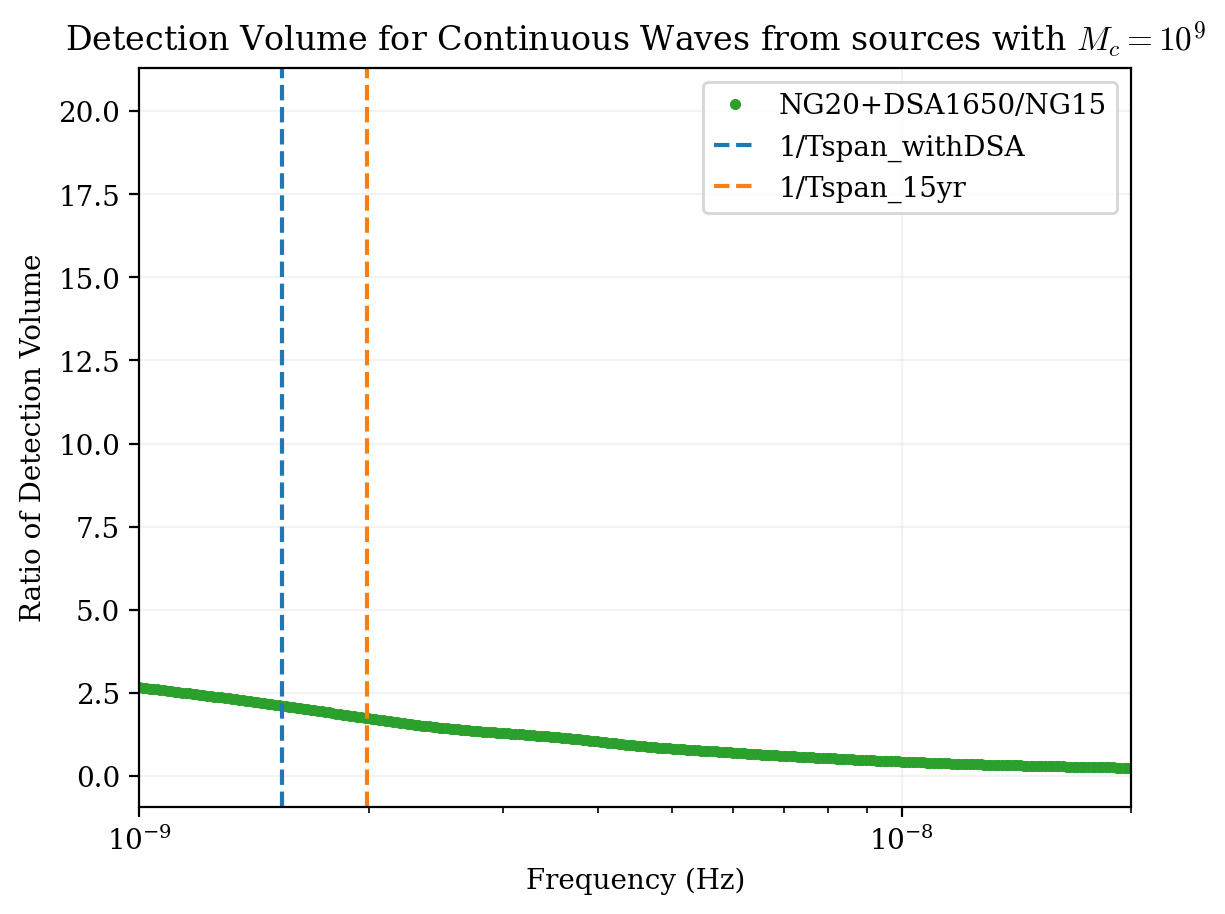

In [33]:
#add frequency lines for 1/(15 years) and 1/(20 years)
f_dsa = 1/ng20_sens.Tspan
print('1/Tspan_DSA:', ng20_sens.Tspan/(365*86400))
print(f_dsa)
f_15 = 1/sliced_GWBSC.Tspan #tspan for the 15 year slice
#plt.plot(freqs,dv_ratio,label='Full NG20/15yr slice')
#plt.axvspan(1e-8, plt.xlim()[1], color='gray', alpha=0.2, label='White noise dominated frequencies')
fyr = 1/(365.25*24*3600)
mask = (freqs < 0.7 * fyr) | (freqs > 1.12 * fyr)
plt.plot(freqs[mask], dv_ratio[mask],'.',label='NG20+DSA1650/NG15',color='C2')
plt.axvline(f_dsa,linestyle='--',label='1/Tspan_withDSA',color='C0')
plt.axvline(f_15,linestyle='--',label='1/Tspan_15yr',color='C1')
plt.xscale('log')
#plt.loglog(freqs,dv_15yr_20,label='15yr slice of NG20')
plt.xlim(1e-9,2e-8)
#plt.ylim(1,8)
#plt.grid(which='both')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Ratio of Detection Volume')
plt.title('Detection Volume for Continuous Waves from sources with $M_c=10^9$')
plt.legend()
plt.savefig('ng20_ng15_with_dmx_detection_volume_ratio_mc1e9_3sigma.png',dpi=300)
plt.show()

### 4) Single source detection probabilities - Dave's populations with 15-year frequency spacing

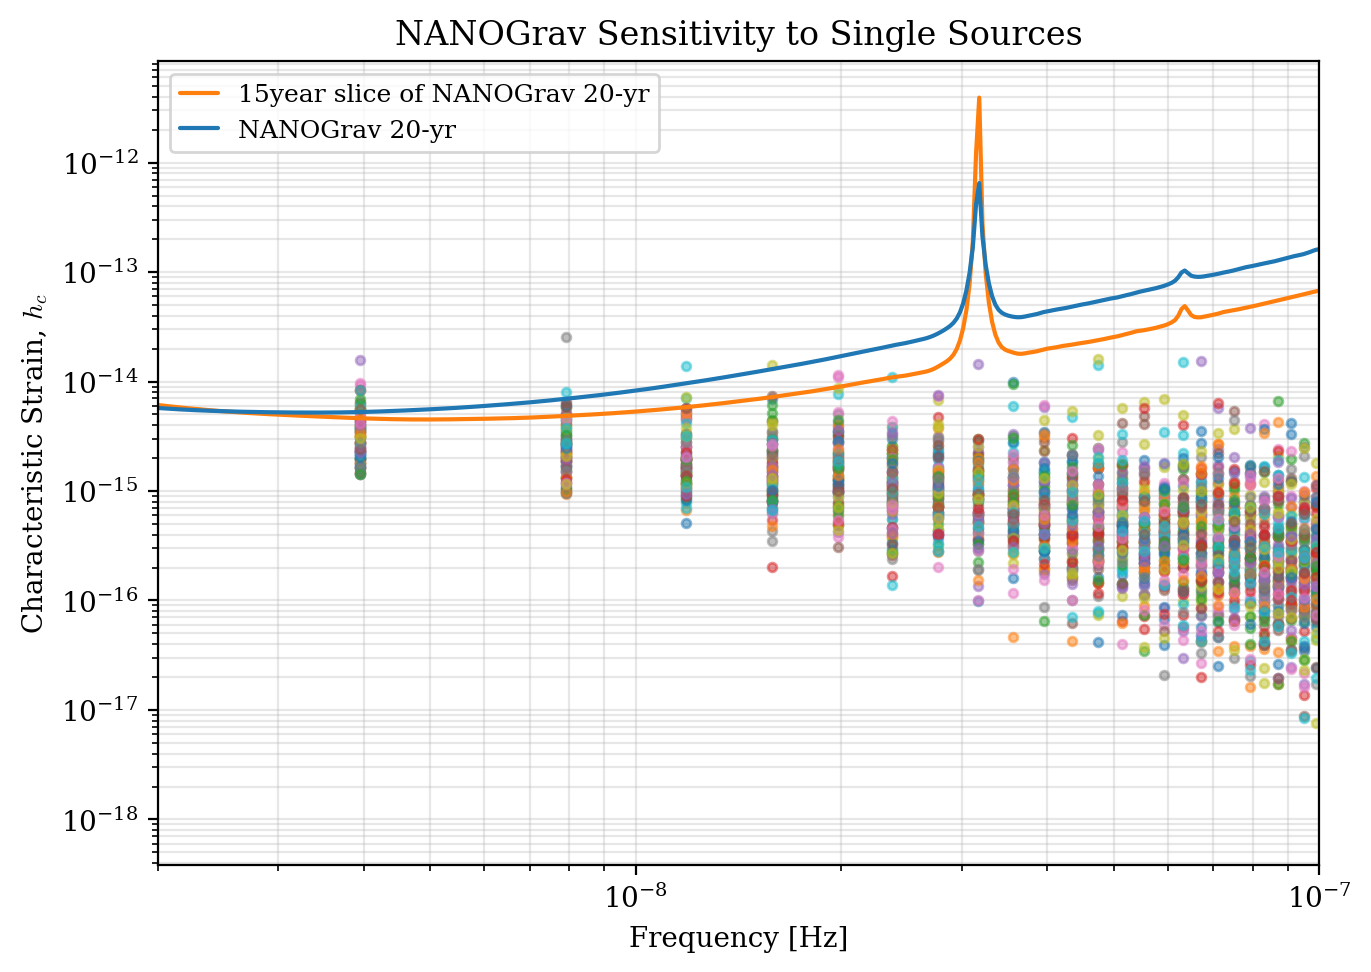

In [34]:
data = h5py.File('pop-draw-sims-15yr.h5', 'r') 
# Number of realizations to plot
plot_num_reals = 10
plot_num_params = 10
# Number of loudest-binaries-per-bin to plot
plot_num_loudest = 1

# ---- Load data

# Frequency bin edges, in units of [1/sec], for orbital frequencies
fobs_orb_edges = data["fobs_orb_edges"][0]  # Just need the first one, they're all the same
# convert to GW frequency centers (assuming circular orbits)
fobs_orb_cents = 0.5 * (fobs_orb_edges[1:] + fobs_orb_edges[:-1])
fobs_gw_cents = 2.0 * fobs_orb_cents #* YR

# Characteristic strains of the L loudest binaries in each of F frequency bins for each of R realizations
# shape: (NParReals, F, R, L)
hc_ss = data["hc_ss"]
npar_reals, nfreqs, nreals, nloudest = hc_ss.shape 
# Characteristic strain of all *other* binaries (i.e. All minus L)
# shape: (NParReals, F, R)
hc_bg = data["hc_bg"]

# can't plot more elements than we have in the data
plot_num_reals = np.minimum(plot_num_reals, nreals)
plot_num_params = np.minimum(plot_num_params, npar_reals)
plot_num_loudest = np.minimum(plot_num_loudest, nloudest)

# ---- Plot GW signals

fig, ax = holo.plot.figax()
for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # this is the combined GWs from all binaries except `L` loudest in each frequency bin
        bg = hc_bg[nr, :, rr]
        # add back in the strains from the loudest binaries that we aren't plotting
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            # Add in quadrature, summing over however many loudest binaries remain
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))
         
        #(hh,) = ax.plot(fobs_gw_cents, bg, alpha=0.75)
        for ll in range(plot_num_loudest):
            ax.scatter(
                fobs_gw_cents, hc_ss[nr, :, rr, ll], s=10, alpha=0.5
            )
            
# Plot a -2/3 power-law of amplitude 1e-15 for reference
#hc_plaw = 1.0e-15 * np.power(fobs_gw_cents, -2.0 / 3.0)
#ax.plot(fobs_gw_cents, hc_plaw, "k--", alpha=0.5, lw=1.0)

#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,color='C3',label='Original NG15')
ax.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr')
#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlim(2e-9,1e-7)
# ---- Labels, legend, and grid
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title(
    'NANOGrav Sensitivity to Single Sources'#\n'
    #f'SNR={sliced_SNR:.2f}'
)
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
#plt.show()
plt.savefig("ng20_ng15_sensitivity_comparison_cws_15year_freq_res.png", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
dp_full = SM_full_20.detection_prob(F_thresh = 3.7, snr=5)#,{'fidx',2})#, Npsrs=None, ave=None, prob_kwargs={'h0':None,'fidx':None})

In [37]:
dp_full

np.float64(0.9963868363264282)

In [38]:
SM_full_20.detection_prob??

Signature:
SM_full_20.detection_prob(
    F_thresh,
    snr=None,
    Npsrs=None,
    ave=None,
    prob_kwargs={'h0': None, 'fidx': None},
)
Source:   
    def detection_prob(self, F_thresh, snr=None, Npsrs=None, ave=None, prob_kwargs={'h0':None,'fidx':None}):
        '''
        Detection probability of the F-statistic. See Rosado et al. 2015 `[3]` equation 32.
        Use None for the Fe and the number of pulsars for the Fp stat.

       Parameters
        ----------
        F_thresh : float,array
            F-statistic threshold

        snr : float, optional
            Signal to noise ratio for a given single source.

        Npsrs : string, optional
            Number of pulsars in the array for using the Fp statistic.
            Use None for the Fe statistic.

        ave : string, optional -- choose from ['none','snr','prob']
            Point at which angle averaging happens for the F-statistic.
            See appendix of Baier et al. 2024 `[2]` for details.
              